In [1]:
pip install timm

/bin/bash: /home/jia/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torchvision
from torchvision import datasets
from torchvision import transforms as T # for simplifying the transforms
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler, random_split, Dataset
from torchvision import models
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
from glob import glob
import cv2
import sys
import timm
import tqdm
from torchvision import datasets
import random
import math
from PIL import Image                                 #Line 3
import torchvision.transforms.functional as TF        #Line 4
from timm.models.layers import to_2tuple
import pandas as pd
from sklearn.metrics import roc_curve, auc, roc_auc_score

/home/jia/anaconda3/envs/xin/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jia/anaconda3/envs/xin/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZNK3c107SymBool10guard_boolEPKcl'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
first_transform = T.Compose([
      T.Resize((224, 224)),
      T.ToTensor(),
  ])


In [4]:
#IMG_PATH = '/content/drive/MyDrive/DL-T Cell Segmentation/June 8th dataset/'

root_tr = '/home/xin/Project/20240603 regression_splitted dataset_patch no overlap/train'
root_val = '/home/xin/Project/20240603 regression_splitted dataset_patch no overlap/val'
root_test = '/home/xin/Project/20240603 regression_splitted dataset_patch no overlap/test'

In [5]:
import os
from glob import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class patch_dataset(Dataset):
    def __init__(self, root_dir, transform):

        self.root_dir = root_dir
        self.path_AlKn_soft = glob(os.path.join(self.root_dir+ '/AlKn_soft_1.97/*.jpg'))
        self.path_AlKn_medium = glob(os.path.join(self.root_dir+ '/AlKn_medium_4.02/*.jpg'))
        self.path_AlKn_hard = glob(os.path.join(self.root_dir+ '/AlKn_hard_3.05/*.jpg'))
        
        self.path_BaMu_soft = glob(os.path.join(self.root_dir+ '/BaMu_soft_3.16/*.jpg'))
        self.path_BaMu_medium = glob(os.path.join(self.root_dir+ '/BaMu_medium_3.65/*.jpg'))
        self.path_BaMu_hard = glob(os.path.join(self.root_dir+ '/BaMu_hard_2.84/*.jpg'))
      
        self.path_KeOb_soft = glob(os.path.join(self.root_dir+ '/KeOb_soft_2.79/*.jpg'))
        self.path_KeOb_medium = glob(os.path.join(self.root_dir+ '/KeOb_medium_2.77/*.jpg'))
        self.path_KeOb_hard = glob(os.path.join(self.root_dir+ '/KeOb_hard_2.19/*.jpg'))
        
        self.path_SaSa_soft = glob(os.path.join(self.root_dir+ '/SaSa_soft_3.87/*.jpg'))
        self.path_SaSa_medium = glob(os.path.join(self.root_dir+ '/SaSa_medium_5.35/*.jpg'))
        self.path_SaSa_hard = glob(os.path.join(self.root_dir+ '/SaSa_hard_4.40/*.jpg'))
        
        self.path_CaLe_soft = glob(os.path.join(self.root_dir+ '/CaLe_soft_4.94/*.jpg'))
        self.path_CaLe_medium = glob(os.path.join(self.root_dir+ '/CaLe_medium_6.08/*.jpg'))
        self.path_CaLe_hard = glob(os.path.join(self.root_dir+ '/CaLe_hard_3.78/*.jpg'))
        
        self.path_DiKa_soft = glob(os.path.join(self.root_dir+ '/DiKa_soft_2.62/*.jpg'))
        self.path_DiKa_medium = glob(os.path.join(self.root_dir+ '/DiKa_medium_3.72/*.jpg'))
        self.path_DiKa_hard = glob(os.path.join(self.root_dir+ '/DiKa_hard_1.11/*.jpg'))
        
        self.path_WiDa_soft = glob(os.path.join(self.root_dir+ '/WiDa_soft_5.13/*.jpg'))
        self.path_WiDa_medium = glob(os.path.join(self.root_dir+ '/WiDa_medium_5.09/*.jpg'))
        self.path_WiDa_hard = glob(os.path.join(self.root_dir+ '/WiDa_hard_2.96/*.jpg'))
      
        self.path_HC5M_soft = glob(os.path.join(self.root_dir+ '/HC5M_soft_4.60/*.jpg'))
        self.path_HC5M_medium = glob(os.path.join(self.root_dir+ '/HC5M_medium_4.77/*.jpg'))
        self.path_HC5M_hard = glob(os.path.join(self.root_dir+ '/HC5M_hard_2.95/*.jpg'))
        
        self.path_HC6F_soft = glob(os.path.join(self.root_dir+ '/HC6F_soft_5.52/*.jpg'))
        self.path_HC6F_medium = glob(os.path.join(self.root_dir+ '/HC6F_medium_5.85/*.jpg'))
        self.path_HC6F_hard = glob(os.path.join(self.root_dir+ '/HC6F_hard_4.00/*.jpg'))
        
        self.path_HC7M_soft = glob(os.path.join(self.root_dir+ '/HC7M_soft_4.54/*.jpg'))
        self.path_HC7M_medium = glob(os.path.join(self.root_dir+ '/HC7M_medium_5.14/*.jpg'))
        self.path_HC7M_hard = glob(os.path.join(self.root_dir+ '/HC7M_hard_3.96/*.jpg'))
        
        self.img_path_list = self.path_WiDa_soft  + self.path_WiDa_medium + self.path_WiDa_hard+self.path_DiKa_soft  + self.path_DiKa_medium + self.path_DiKa_hard+self.path_CaLe_soft  + self.path_CaLe_medium + self.path_CaLe_hard + self.path_SaSa_soft  + self.path_SaSa_medium + self.path_SaSa_hard + self.path_AlKn_soft  + self.path_AlKn_medium + self.path_AlKn_hard + self.path_BaMu_soft + self.path_BaMu_medium + self.path_BaMu_hard + self.path_KeOb_soft + self.path_KeOb_medium + self.path_KeOb_hard + self.path_HC5M_soft+ self.path_HC5M_medium + self.path_HC5M_hard + self.path_HC6F_soft + self.path_HC6F_medium + self.path_HC6F_hard + self.path_HC7M_soft + self.path_HC7M_medium + self.path_HC7M_hard
        self.transform = transform
        self.identity = np.array(range(len(self.img_path_list)), dtype=str)

    def __getitem__(self, idx:int):

        img_name = self.img_path_list[idx]
        current_name = img_name.split('/')[-1]
        img = cv2.imread(img_name, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        #img = np.transpose(img, (2, 0, 1))

        if self.transform is not None:
          img = self.transform(img)
        
        label = None  # Assigning a default value to label
      


        if current_name.split('_')[0] == 'CLLAlKn' and current_name.split('_')[2] == '1to50':
          label = 1.97
        elif current_name.split('_')[0] == 'CLLAlKn' and current_name.split('_')[2] == '1to30':
          label = 4.02
        elif current_name.split('_')[0] == 'CLLAlKn' and current_name.split('_')[2] == '1to10':
          label = 3.05
        elif current_name.split('_')[0] == 'CLLBaMu' and current_name.split('_')[2] == '1to50':
          label = 3.16
        elif current_name.split('_')[0] == 'CLLBaMu' and current_name.split('_')[2] == '1to30':
          label = 3.65
        elif current_name.split('_')[0] == 'CLLBaMu' and current_name.split('_')[2] == '1to10':
          label = 2.84
        elif current_name.split('_')[0] == 'CLLKeOb' and current_name.split('_')[2] == '1to50':
          label = 2.79
        elif current_name.split('_')[0] == 'CLLKeOb' and current_name.split('_')[2] == '1to30':
          label = 2.77
        elif current_name.split('_')[0] == 'CLLKeOb' and current_name.split('_')[2] == '1to10':
          label = 2.19
        elif current_name.split('_')[0] == 'CLLSaSa' and current_name.split('_')[2] == '1to10':
          label = 4.40
        elif current_name.split('_')[0] == 'CLLSaSa' and current_name.split('_')[2] == '1to30':
          label = 5.35
        elif current_name.split('_')[0] == 'CLLSaSa' and current_name.split('_')[2] == '1to50':
          label = 3.87
        elif current_name.split('_')[0] == 'CLLCaLe' and current_name.split('_')[2] == '1to10':
          label = 3.78
        elif current_name.split('_')[0] == 'CLLCaLe' and current_name.split('_')[2] == '1to30':
          label = 6.08
        elif current_name.split('_')[0] == 'CLLCaLe' and current_name.split('_')[2] == '1to50':
          label = 4.94
        elif current_name.split('_')[0] == 'CLLDiKa' and current_name.split('_')[2] == '1to10':
          label = 1.11
        elif current_name.split('_')[0] == 'CLLDiKa' and current_name.split('_')[2] == '1to30':
          label =3.72
        elif current_name.split('_')[0] == 'CLLDiKa' and current_name.split('_')[2] == '1to50':
          label = 2.62
        elif current_name.split('_')[0] == 'CLLWiDa' and current_name.split('_')[2] == '1to10':
          label = 2.96
        elif current_name.split('_')[0] == 'CLLWiDa' and current_name.split('_')[2] == '1to30':
          label =5.09
        elif current_name.split('_')[0] == 'CLLWiDa' and current_name.split('_')[2] == '1to50':
          label = 5.13
      
        elif current_name.split('_')[0] == 'HC5M' and current_name.split('_')[2] == '1to50':
          label = 4.60
        elif current_name.split('_')[0] == 'HC5M' and current_name.split('_')[2] == '1to30':
          label = 4.77
        elif current_name.split('_')[0] == 'HC5M' and current_name.split('_')[2] == '1to10':
          label = 2.95
        elif current_name.split('_')[0] == 'HC6F' and current_name.split('_')[2] == '1to50':
          label = 5.52
        elif current_name.split('_')[0] == 'HC6F' and current_name.split('_')[2] == '1to30':
          label = 5.85
        elif current_name.split('_')[0] == 'HC6F' and current_name.split('_')[2] == '1to10':
          label = 4.00
        elif current_name.split('_')[0] == 'HC7M' and current_name.split('_')[2] == '1to50':
          label = 4.54
        elif current_name.split('_')[0] == 'HC7M' and current_name.split('_')[2] == '1to30':
          label = 5.14
        elif current_name.split('_')[0] == 'HC7M' and current_name.split('_')[2] == '1to10':
          label = 3.96
        
        if label is None:
            raise ValueError(f"No label assigned for image {img_name}")
                             
        sample = {'image': img, 'label': torch.tensor(label, dtype=torch.float32), 'idx': idx, 'filename':current_name}
        
        return sample

    def __len__(self):
        return len(self.img_path_list)

In [6]:
train_dataset = torchvision.datasets.ImageFolder(root = root_tr, transform = first_transform)
valid_dataset = torchvision.datasets.ImageFolder(root = root_val, transform = first_transform)
test_dataset = torchvision.datasets.ImageFolder(root = root_test, transform = first_transform)
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=len(train_dataset), num_workers=2)
validloader = torch.utils.data.DataLoader(valid_dataset, batch_size=len(valid_dataset), num_workers=2)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=len(test_dataset), num_workers =2)

In [7]:
print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

27540
3440
3445


In [8]:
# normalize: Gaussian distribution, if some images are very dim, turn brighter

train_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    
])


val_transform = T.Compose([
      T.ToPILImage(),
      T.ToTensor(),
      
])

test_transform = T.Compose([
      T.ToPILImage(),
      T.ToTensor(),
      
])

In [9]:
try_dataset = patch_dataset(root_test, test_transform)
#to visualize using an example

CLLDiKa_20240330_1to10_40min_1_03_p24.jpg
(224, 224, 3)
label tensor(1.1100)
identity 400


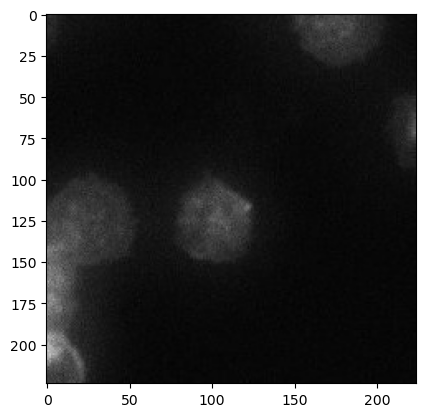

In [10]:
batch = try_dataset.__getitem__(400)
img = batch['image'].numpy()
img = img
img = np.transpose(img, (1,2,0))
img_name=batch['filename']
print(img_name)

print(img.shape)
label = batch['label']
plt.imshow(img)
print('label',label)
print('identity', batch['idx'])

In [11]:
def number_of_imgs(path):

  class_num = []
  for value in os.listdir(path):
    total_num = 0
    print(value, "has", len(os.listdir(path + "/" + value)), "imgs")
    total_num = total_num + len(os.listdir(path + "/" + value))
    #total_num = total_num + len(os.listdir(patvalue))
    class_num.append(total_num)
  print('\n')
  return sum(class_num)



ratio = number_of_imgs(root_test) #train dataset

print(ratio)
#print(val_num)

DiKa_hard_1.11 has 75 imgs
HC6F_medium_5.85 has 75 imgs
AlKn_hard_3.05 has 75 imgs
HC6F_soft_5.52 has 75 imgs
CaLe_hard_3.78 has 150 imgs
WiDa_soft_5.13 has 65 imgs
CaLe_soft_4.94 has 138 imgs
CaLe_medium_6.08 has 138 imgs
SaSa_medium_5.35 has 75 imgs
HC7M_medium_5.14 has 80 imgs
KeOb_hard_2.19 has 175 imgs
AlKn_soft_1.97 has 75 imgs
HC5M_soft_4.60 has 178 imgs
HC5M_medium_4.77 has 198 imgs
WiDa_medium_5.09 has 70 imgs
BaMu_hard_2.84 has 153 imgs
DiKa_medium_3.72 has 75 imgs
HC7M_soft_4.54 has 125 imgs
BaMu_medium_3.65 has 150 imgs
WiDa_hard_2.96 has 75 imgs
KeOb_soft_2.79 has 175 imgs
SaSa_hard_4.40 has 75 imgs
DiKa_soft_2.62 has 75 imgs
SaSa_soft_3.87 has 75 imgs
HC7M_hard_3.96 has 125 imgs
HC6F_hard_4.00 has 75 imgs
BaMu_soft_3.16 has 150 imgs
HC5M_hard_2.95 has 225 imgs
KeOb_medium_2.77 has 175 imgs
AlKn_medium_4.02 has 75 imgs


3445


In [20]:
print(root_tr)

/home/xin/Project/20240502 regression_no patch overlap_splitted dataset/train


In [12]:

HUB_URL = "SharanSMenon/swin-transformer-hub:main" 
MODEL_NAME = "swin_tiny_patch4_window7_224"
# check hubconf for more models.


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#num_classes = 1 
model = torch.hub.load(HUB_URL, MODEL_NAME, pretrained=True) # load from torch hub
#automatically download from HUBURL
#for param in model.parameters():
    #param.requires_grad = True

n_inputs = model.head.in_features
model.head = nn.Sequential(
    nn.Linear(n_inputs, 64),
    nn.ReLU(), #activation, nonlinear--increase generalization
    nn.Dropout(0.2), #20% nodes drop out
    nn.Linear(64, 1), 
    #nn.Sigmoid()
)
print(model.head)
model = model.to(device)



Using cache found in /home/xin/.cache/torch/hub/SharanSMenon_swin-transformer-hub_main
/home/jia/anaconda3/envs/xin/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Sequential(
  (0): Linear(in_features=768, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=1, bias=True)
)


In [14]:


optimizer = optim.Adam(model.parameters(), lr=1e-6)
num_epochs =  250

In [15]:


bs = 64

train_dataset = patch_dataset(root_dir = root_tr, transform = train_transform)
valid_dataset = patch_dataset(root_dir = root_val, transform = val_transform)
test_dataset = patch_dataset(root_dir = root_test, transform = test_transform)
#to normalize, train--random rotate

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=bs, num_workers=2, shuffle = True)
validloader = torch.utils.data.DataLoader(valid_dataset, batch_size=bs, num_workers=2, shuffle = True)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=bs, num_workers=2, shuffle = False)


train_filenames = glob(os.path.join(root_tr + '/WiDa_soft_5.13/*.jpg'))+glob(os.path.join(root_tr + '/WiDa_medium_5.09/*.jpg'))+glob(os.path.join(root_tr + '/WiDa_hard_2.96/*.jpg'))+glob(os.path.join(root_tr + '/DiKa_soft_2.62/*.jpg'))+glob(os.path.join(root_tr + '/DiKa_medium_3.72/*.jpg')) + glob(os.path.join(root_tr + '/DiKa_hard_1.11/*.jpg'))+glob(os.path.join(root_tr + '/CaLe_soft_4.94/*.jpg'))+glob(os.path.join(root_tr + '/CaLe_medium_5.72/*.jpg')) + glob(os.path.join(root_tr + '/CaLe_hard_3.78/*.jpg'))+glob(os.path.join(root_tr + '/SaSa_soft_4.22/*.jpg'))+glob(os.path.join(root_tr + '/SaSa_medium_5.93/*.jpg')) + glob(os.path.join(root_tr + '/SaSa_hard_5.26/*.jpg'))+glob(os.path.join(root_tr + '/AlKn_hard_3.05/*.jpg')) + glob(os.path.join(root_tr + '/AlKn_medium_4.02/*.jpg')) + glob(os.path.join(root_tr + '/AlKn_soft_1.97/*.jpg')) + glob(os.path.join(root_tr + '/BaMu_hard_2.84/*.jpg')) + glob(os.path.join(root_tr + '/BaMu_medium_3.65/*.jpg')) + glob(os.path.join(root_tr + '/BaMu_soft_3.16/*.jpg')) + glob(os.path.join(root_tr + '/HC5M_hard_2.95/*.jpg')) + glob(os.path.join(root_tr + '/HC5M_medium_4.77/*.jpg')) + glob(os.path.join(root_tr + '/HC5M_soft_4.60/*.jpg')) + glob(os.path.join(root_tr + '/HC6F_hard_4.00/*.jpg')) + glob(os.path.join(root_tr + '/HC6F_medium_5.85/*.jpg')) + glob(os.path.join(root_tr + '/HC6F_soft_5.52/*.jpg')) + glob(os.path.join(root_tr + '/HC7M_hard_3.96/*.jpg')) + glob(os.path.join(root_tr + '/HC7M_medium_5.14/*.jpg')) + glob(os.path.join(root_tr + '/HC7M_soft_4.54/*.jpg')) + glob(os.path.join(root_tr + '/KeOb_hard_2.19/*.jpg')) + glob(os.path.join(root_tr + '/KeOb_medium_2.77/*.jpg')) + glob(os.path.join(root_tr + '/KeOb_soft_2.79/*.jpg'))
valid_filenames = glob(os.path.join(root_val + '/WiDa_soft_5.13/*.jpg'))+glob(os.path.join(root_val + '/WiDa_medium_5.09/*.jpg'))+glob(os.path.join(root_val + '/WiDa_hard_2.96/*.jpg'))+glob(os.path.join(root_val + '/DiKa_soft_2.62/*.jpg'))+glob(os.path.join(root_val + '/DiKa_medium_3.72/*.jpg')) + glob(os.path.join(root_val + '/DiKa_hard_1.11/*.jpg'))+glob(os.path.join(root_val + '/CaLe_soft_4.94/*.jpg'))+glob(os.path.join(root_val + '/CaLe_medium_5.72/*.jpg')) + glob(os.path.join(root_val + '/CaLe_hard_3.78/*.jpg'))+glob(os.path.join(root_val + '/SaSa_soft_4.22/*.jpg'))+glob(os.path.join(root_val + '/SaSa_medium_5.93/*.jpg')) + glob(os.path.join(root_val + '/SaSa_hard_5.26/*.jpg'))+glob(os.path.join(root_val + '/AlKn_hard_3.05/*.jpg')) + glob(os.path.join(root_val + '/AlKn_medium_4.02/*.jpg')) + glob(os.path.join(root_val + '/AlKn_soft_1.97/*.jpg')) + glob(os.path.join(root_val + '/BaMu_hard_2.84/*.jpg')) + glob(os.path.join(root_val + '/BaMu_medium_3.65/*.jpg')) + glob(os.path.join(root_val + '/BaMu_soft_3.16/*.jpg')) + glob(os.path.join(root_val + '/HC5M_hard_2.95/*.jpg')) + glob(os.path.join(root_val + '/HC5M_medium_4.77/*.jpg')) + glob(os.path.join(root_val + '/HC5M_soft_4.60/*.jpg')) + glob(os.path.join(root_val + '/HC6F_hard_4.00/*.jpg')) + glob(os.path.join(root_val + '/HC6F_medium_5.85/*.jpg')) + glob(os.path.join(root_val + '/HC6F_soft_5.52/*.jpg')) + glob(os.path.join(root_val + '/HC7M_hard_3.96/*.jpg')) + glob(os.path.join(root_val + '/HC7M_medium_5.14/*.jpg')) + glob(os.path.join(root_val + '/HC7M_soft_4.54/*.jpg')) + glob(os.path.join(root_val + '/KeOb_hard_2.19/*.jpg')) + glob(os.path.join(root_val + '/KeOb_medium_2.77/*.jpg')) + glob(os.path.join(root_val + '/KeOb_soft_2.79/*.jpg'))
test_filenames = glob(os.path.join(root_test + '/WiDa_soft_5.13/*.jpg'))+glob(os.path.join(root_test + '/WiDa_medium_5.09/*.jpg'))+glob(os.path.join(root_test + '/WiDa_hard_2.96/*.jpg'))+glob(os.path.join(root_test + '/DiKa_soft_2.62/*.jpg'))+glob(os.path.join(root_test + '/DiKa_medium_3.72/*.jpg')) + glob(os.path.join(root_test + '/DiKa_hard_1.11/*.jpg'))+glob(os.path.join(root_test + '/CaLe_soft_4.94/*.jpg'))+glob(os.path.join(root_test + '/CaLe_medium_5.72/*.jpg')) + glob(os.path.join(root_test + '/CaLe_hard_3.78/*.jpg'))+glob(os.path.join(root_test + '/SaSa_soft_4.22/*.jpg'))+glob(os.path.join(root_test + '/SaSa_medium_5.93/*.jpg')) + glob(os.path.join(root_test + '/SaSa_hard_5.26/*.jpg'))+glob(os.path.join(root_test + '/AlKn_hard_3.05/*.jpg')) + glob(os.path.join(root_test + '/AlKn_medium_4.02/*.jpg')) + glob(os.path.join(root_test + '/AlKn_soft_1.97/*.jpg')) + glob(os.path.join(root_test + '/BaMu_hard_2.84/*.jpg')) + glob(os.path.join(root_test + '/BaMu_medium_3.65/*.jpg')) + glob(os.path.join(root_test + '/BaMu_soft_3.16/*.jpg')) + glob(os.path.join(root_test + '/HC5M_hard_2.95/*.jpg')) + glob(os.path.join(root_test + '/HC5M_medium_4.77/*.jpg')) + glob(os.path.join(root_test + '/HC5M_soft_4.60/*.jpg')) + glob(os.path.join(root_test + '/HC6F_hard_4.00/*.jpg')) + glob(os.path.join(root_test + '/HC6F_medium_5.85/*.jpg')) + glob(os.path.join(root_test + '/HC6F_soft_5.52/*.jpg')) + glob(os.path.join(root_test + '/HC7M_hard_3.96/*.jpg')) + glob(os.path.join(root_test + '/HC7M_medium_5.14/*.jpg')) + glob(os.path.join(root_test + '/HC7M_soft_4.54/*.jpg')) + glob(os.path.join(root_test + '/KeOb_hard_2.19/*.jpg')) + glob(os.path.join(root_test + '/KeOb_medium_2.77/*.jpg')) + glob(os.path.join(root_test + '/KeOb_soft_2.79/*.jpg'))


In [20]:
 len(testloader)

54

In [16]:


from sklearn.metrics import r2_score

train_acc = []
train_result = []
valid_acc = []
valid_result = []
bs = bs




def train_net(patience, number_id):

    trigger_times = 0

    # Start print
    print('--------------------------------')


    print('--------------------------------')

#      


    n_train = len(trainloader)
    n_valid = len(validloader)

    train_loss = []
    valid_loss = []
    train_r2 = []
    valid_r2 = []

    loss_function = nn.MSELoss().to(device)


    # Run the training loop for defined number of epochs
    for epoch in range(0, num_epochs):

        # Print epoch
        print(f'Starting epoch {epoch+1}')
        model.train()
        epoch_train_loss = 0
        train_preds = []
        train_labels = []

        # Iterate over the DataLoader for training data
        for i, batch in enumerate(trainloader):
                

                inputs = batch['image'].to(device)
                labels = batch['label'].float().view(inputs.size(0), 1).to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                
                # Compute loss
                loss = loss_function(outputs, labels)

            
                # Perform backward pass
                loss.backward()

                # Perform optimization
                optimizer.step()
                # exp_lr_scheduler.step()
                epoch_train_loss += loss.item() * inputs.size(0)
                train_preds.extend(outputs.cpu().detach().numpy())
                train_labels.extend(labels.cpu().detach().numpy())
                
        epoch_train_loss /= len(trainloader.dataset)
        train_loss.append(epoch_train_loss)
                
        train_r2_value = r2_score(train_labels, train_preds)
        train_r2.append(train_r2_value)

            

        

        model.eval()
        epoch_valid_loss = 0
        valid_preds = []
        valid_labels = []

        with torch.set_grad_enabled(False):

            # Iterate over the test data and generate predictions
                for i, batch in enumerate(validloader):
                    

                    inputs = batch['image'].to(device)
                    labels = batch['label'].float().view(inputs.size(0),1).to(device)


                    outputs = model(inputs)


                    

                    loss = loss_function(outputs, labels)
                    # print('loss', loss)
                    epoch_valid_loss += loss.item() * inputs.size(0)
                    valid_preds.extend(outputs.cpu().detach().numpy())
                    valid_labels.extend(labels.cpu().detach().numpy())
                
                epoch_valid_loss /= len(validloader.dataset)
                valid_loss.append(epoch_valid_loss)

                valid_r2_value = r2_score(valid_labels, valid_preds)
                valid_r2.append(valid_r2_value)
                
        save_dict = {
           'model_state_dict': model.state_dict(),
           'train_loss': train_loss,
           'train_r2': train_r2,
           'valid_loss': valid_loss,
           'valid_r2': valid_r2
        }
        
        save_path = f'/home/xin/Project/20240603 regression full data corrected_nonoverlap_saved model/epoch_{epoch+1:03}.pth'
        torch.save(save_dict, save_path)

            

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Valid Loss: {epoch_valid_loss:.4f}, Train R2: {train_r2_value:.4f}, Valid R2: {valid_r2_value:.4f}')

        
    return train_loss, train_r2, valid_loss, valid_r2, train_filenames, valid_filenames

In [18]:
number_id = 2
avg_train_loss, avg_train_r2, avg_valid_loss, avg_valid_r2, train_filenames, valid_filenames = train_net(3, number_id)

--------------------------------
--------------------------------
Starting epoch 1


Epoch [1/250], Train Loss: 5.5651, Valid Loss: 1.2396, Train R2: -3.1918, Valid R2: 0.0661
Starting epoch 2
Epoch [2/250], Train Loss: 1.5343, Valid Loss: 1.1802, Train R2: -0.1557, Valid R2: 0.1108
Starting epoch 3
Epoch [3/250], Train Loss: 1.4447, Valid Loss: 1.1630, Train R2: -0.0882, Valid R2: 0.1238
Starting epoch 4
Epoch [4/250], Train Loss: 1.4074, Valid Loss: 1.1491, Train R2: -0.0601, Valid R2: 0.1343
Starting epoch 5
Epoch [5/250], Train Loss: 1.3759, Valid Loss: 1.1309, Train R2: -0.0364, Valid R2: 0.1480
Starting epoch 6
Epoch [6/250], Train Loss: 1.3531, Valid Loss: 1.1191, Train R2: -0.0192, Valid R2: 0.1568
Starting epoch 7
Epoch [7/250], Train Loss: 1.3405, Valid Loss: 1.1095, Train R2: -0.0097, Valid R2: 0.1641
Starting epoch 8
Epoch [8/250], Train Loss: 1.3210, Valid Loss: 1.1035, Train R2: 0.0050, Valid R2: 0.1686
Starting epoch 9
Epoch [9/250], Train Loss: 1.3087, Valid Loss: 1.0923, Train R2: 0.0142, Valid R2: 0.1770
Starting epoch 10
Epoch [10/250], Train Loss: 1

118


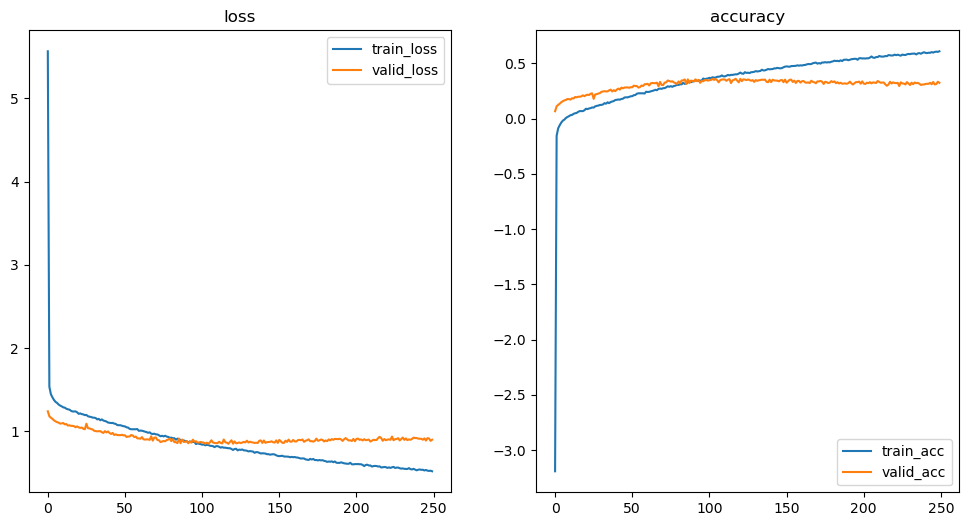

In [19]:
# best_epoch = (np.argmin(avg_valid_loss) + 1)
best_epoch = (np.argmax(avg_valid_r2) + 1)
print(best_epoch)
plt.figure(figsize = [12, 6])
plt.subplot(121)
plt.plot(avg_train_loss, label="train_loss")
plt.plot(avg_valid_loss, label="valid_loss")
plt.title('loss')
plt.legend()

plt.subplot(122)
plt.plot(avg_train_r2, label="train_acc")
plt.plot(avg_valid_r2, label="valid_acc")
plt.title('accuracy')
plt.legend()

In [17]:
best_epoch = 118  # Change this to the epoch you want to load
save_path = f'/home/xin/Project/20240603 regression full data corrected_nonoverlap_saved model/epoch_{best_epoch:03}.pth'

# Load the saved dictionary
saved_dict = torch.load(save_path)

# Extract the model state dictionary
model_state_dict = saved_dict['model_state_dict']

# Load the model's state dictionary
model.load_state_dict(model_state_dict)

# Move the model to the appropriate device (e.g., GPU)
model.cuda()  # Assuming you're using GPU

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (layers): ModuleList(
    (0): BasicLayer(
      dim=96, input_resolution=(56, 56), depth=2
      (blocks): ModuleList(
        (0): SwinTransformerBlock(
          dim=96, input_resolution=(56, 56), num_heads=3, window_size=7, shift_size=0, mlp_ratio=4.0
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            dim=96, window_size=(7, 7), num_heads=3
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path): Identity()
          (norm2): LayerNo

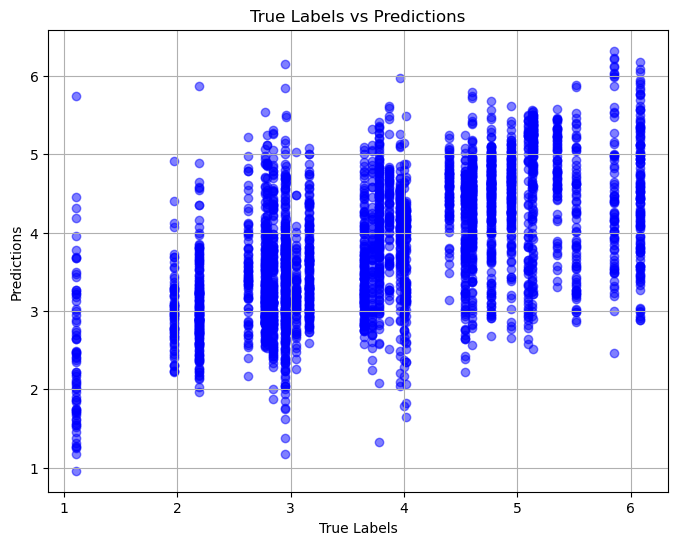

R2 score on test set: 0.311002407157145


In [18]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np
from scipy.stats import gaussian_kde

def evaluate_model(model, testloader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in testloader:
            inputs = batch['image'].to(device)
            labels = batch['label'].float().to(device)
        

            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(outputs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Plot true labels vs predictions
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, color='blue', alpha=0.5)
    plt.title('True Labels vs Predictions')
    plt.xlabel('True Labels')
    plt.ylabel('Predictions')
    plt.grid(True)
    plt.show()
    
    return r2

test_r2 = evaluate_model(model, testloader)

print(f"R2 score on test set: {test_r2}")


In [29]:
import re
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score




def rank_stiffness(result, all_filenames):
    idx = result[:, 1]
    pred = result[:, 2]
    label = result[:, 0]

    donor_stiffness_dict = {}
     # Dictionary to store predicted values for each donor-stiffness combination
    donor_stiffness_label = {}
    for i in range(len(idx)):
        i = int(idx[i])
        curr_identity = all_filenames[i].split('/')[-1]
        donor = curr_identity.split('_')[0]
        stiffness_level = curr_identity.split('_')[2]
        image_name = '_'.join([donor, stiffness_level])

        if image_name in donor_stiffness_dict:
            donor_stiffness_dict[image_name].append(pred[i])
            donor_stiffness_label[image_name].append(label[i])
        else:
            donor_stiffness_dict[image_name] = [pred[i]]
            donor_stiffness_label[image_name] = [label[i]]
    
    # Print out predictions for each donor and stiffness level
    print("Predictions for each donor and stiffness level:")

        
    donor_mean_values = {}
    donor_true_mean_values = {}

#calculate the mean for each donor_stiffness combination
    for key in donor_stiffness_dict:
        donor, stiffness = key.split('_')
        kde = gaussian_kde(donor_stiffness_dict[key])
        mean_value = np.mean(donor_stiffness_dict[key])
        true_mean_value = np.mean(donor_stiffness_label[key])

        if donor not in donor_mean_values:
            donor_mean_values[donor] = {}
            donor_true_mean_values[donor] = {}
        donor_mean_values[donor][stiffness] = mean_value
        donor_true_mean_values[donor][stiffness] = true_mean_value
        
#identify stiffness with the highest mean value for each donor
    donor_best_stiffness = {}
    donor_best_true_stiffness = {}

    for donor, stiffness_values in donor_mean_values.items():
        best_stiffness = max(stiffness_values, key=stiffness_values.get)
        best_true_stiffness = max(donor_true_mean_values[donor], key=donor_true_mean_values[donor].get)
        donor_best_stiffness[donor] = best_stiffness
        donor_best_true_stiffness[donor] = best_true_stiffness

    print("Stiffness level with the highest mean value for each donor (based on predicted values):")
    for donor, stiffness in donor_best_stiffness.items():
        print(f"Donor: {donor}, Best Stiffness: {stiffness}")

    print("Stiffness level with the highest mean value for each donor (based on true labels):")
    for donor, stiffness in donor_best_true_stiffness.items():
        print(f"Donor: {donor}, Best Stiffness: {stiffness}")

    stiffness_map = {'1to10': 0, '1to30': 1, '1to50': 2}
    true_labels_numeric = [stiffness_map[label] for label in list(donor_best_true_stiffness.values())]
    predicted_labels_numeric = [stiffness_map[label] for label in list(donor_best_stiffness.values())]

    accuracy = accuracy_score(true_labels_numeric, predicted_labels_numeric)
    confusion = confusion_matrix(true_labels_numeric, predicted_labels_numeric, labels=[0, 1, 2])
    auc = roc_auc_score(true_labels_numeric, predicted_labels_numeric, multi_class='ovo', labels=[0, 1, 2])

    print(f"Accuracy: {accuracy}")
    print(f"AUC: {auc}")

    sensitivity, specificity, overall_sensitivity, overall_specificity = calculate_sensitivity_specificity(confusion)

    print(f"Sensitivity: {sensitivity}")
    print(f"Specificity: {specificity}")
    print(f"Overall Sensitivity: {overall_sensitivity}")
    print(f"Overall Specificity: {overall_specificity}")

    plot_confusion_matrix(confusion, labels=['1to10', '1to30', '1to50'])

    plot_scatter_plot(donor_stiffness_dict, donor_stiffness_label)
    return donor_stiffness_dict

def calculate_sensitivity_specificity(conf_matrix):
    sensitivity = {}
    specificity = {}

    total_TP = 0
    total_TN = 0
    total_FP = 0
    total_FN = 0

    for i in range(conf_matrix.shape[0]):
        TP = conf_matrix[i, i]
        FN = conf_matrix[i, :].sum() - TP
        FP = conf_matrix[:, i].sum() - TP
        TN = conf_matrix.sum() - (TP + FN + FP)
        
        sensitivity[i] = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity[i] = TN / (TN + FP) if (TN + FP) > 0 else 0

        total_TP += TP
        total_TN += TN
        total_FP += FP
        total_FN += FN

    overall_sensitivity = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0
    overall_specificity = total_TN / (total_TN + total_FP) if (total_TN + total_FP) > 0 else 0

    return sensitivity, specificity, overall_sensitivity, overall_specificity

import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(confusion, labels):
    # Map the original labels to the new ones
    label_mapping = {'1to10': 'Hard', '1to30': 'Medium', '1to50': 'Soft'}
    new_labels = [label_mapping[label] for label in labels]  # Replace labels with the mapped names

    plt.figure(figsize=(8, 6))  # Adjust figure size for better readability
    plt.imshow(confusion, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix', fontsize=20)  # Set title font size
    plt.colorbar()

    tick_marks = np.arange(len(new_labels))
    plt.xticks(tick_marks, new_labels, rotation=45, fontsize=15)  # Set x-axis tick font size
    plt.yticks(tick_marks, new_labels, fontsize=15)  # Set y-axis tick font size

    # Annotate each cell in the confusion matrix
    thresh = confusion.max() / 2.  # Threshold for text color
    for i, j in np.ndindex(confusion.shape):
        plt.text(j, i, format(confusion[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if confusion[i, j] > thresh else "black",
                 fontsize=20,  # Set text font size
                 fontweight='bold')  # Make text bold

    plt.ylabel('True Label', fontsize=15, fontweight='bold')  # Set y-axis label font size and bold
    plt.xlabel('Predicted Label', fontsize=15, fontweight='bold')  # Set x-axis label font size and bold
    plt.tight_layout()
    plt.show()


def plot_scatter_plot(donor_stiffness_dict, donor_stiffness_label):
    colors = {'CLLAlKn': 'blue', 'CLLBaMu': 'green', 'CLLKeOb': 'red', 'HC5M': 'c', 'HC6F': 'magenta', 'HC7M': 'yellow', 'CLLSaSa': 'pink', 'CLLCaLe': 'orange', 'CLLDiKa': 'purple', 'CLLWiDa': 'brown'}
    markers = {'1to10': 'o', '1to30': 's', '1to50': '^'}

    plt.figure()
    
    for key in donor_stiffness_dict:
        donor, stiffness = key.split('_')
        plt.scatter(donor_stiffness_label[key], donor_stiffness_dict[key], color=colors[donor], marker=markers[stiffness], label=f'{donor}_{stiffness}')
        
        # Calculate the mean value
        mean_value = np.mean(donor_stiffness_dict[key])
        mean_label = np.mean(donor_stiffness_label[key])
        plt.scatter(
            mean_label, mean_value,
            s=200, facecolors='none', edgecolors='black', linewidths=2,
            label=f'{donor}_{stiffness}_mean'
        )


    plt.xlabel('True Label')
    plt.ylabel('Prediction')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Scatter Plot for All Donors and Stiffness Levels')
    plt.show()

In [30]:
#for regression
 
import numpy as np
from sklearn.metrics import mean_squared_error


def test_net(net, test_dataloader, num):

    net.eval()

  
    batch_test_loss = list()
    result = np.zeros((num, 3))
    
    all_labels=[]
    all_predictions=[]
 


    loss_function = nn.MSELoss().to(device)
    all_filenames = [] 

    
    with torch.no_grad():
        for i, batch in enumerate(test_dataloader):


            # Load a batch and pass it to the GPU
            test_correct = 0
            imgs = batch['image'].to(device)

            labels = batch['label'].float().view(imgs.size(0),1).to(device)
            #print(labels)
            idx = batch['idx'].int().view(imgs.size(0),1).to(device)

            y_pred = net(imgs)
              
            batch_result = np.concatenate((labels.cpu().numpy(), idx.cpu().numpy(), y_pred.cpu()), axis=1)
            all_filenames.extend(batch['filename'])

            
            bs_num = bs
            if i == len(test_dataloader)-1:
                result[(i)*bs_num:,:] = batch_result
            else:
                result[(i)*bs_num:(i)*bs_num + bs_num,:] = batch_result
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(y_pred.cpu().numpy())
    


    donor_stiffness_dict = rank_stiffness(result, all_filenames)
    return donor_stiffness_dict


        
        





DiKa_hard_1.11 has 75 imgs
HC6F_medium_5.85 has 75 imgs
AlKn_hard_3.05 has 75 imgs
HC6F_soft_5.52 has 75 imgs
CaLe_hard_3.78 has 150 imgs
WiDa_soft_5.13 has 65 imgs
CaLe_soft_4.94 has 138 imgs
CaLe_medium_6.08 has 138 imgs
SaSa_medium_5.35 has 75 imgs
HC7M_medium_5.14 has 80 imgs
KeOb_hard_2.19 has 175 imgs
AlKn_soft_1.97 has 75 imgs
HC5M_soft_4.60 has 178 imgs
HC5M_medium_4.77 has 198 imgs
WiDa_medium_5.09 has 70 imgs
BaMu_hard_2.84 has 153 imgs
DiKa_medium_3.72 has 75 imgs
HC7M_soft_4.54 has 125 imgs
BaMu_medium_3.65 has 150 imgs
WiDa_hard_2.96 has 75 imgs
KeOb_soft_2.79 has 175 imgs
SaSa_hard_4.40 has 75 imgs
DiKa_soft_2.62 has 75 imgs
SaSa_soft_3.87 has 75 imgs
HC7M_hard_3.96 has 125 imgs
HC6F_hard_4.00 has 75 imgs
BaMu_soft_3.16 has 150 imgs
HC5M_hard_2.95 has 225 imgs
KeOb_medium_2.77 has 175 imgs
AlKn_medium_4.02 has 75 imgs




Predictions for each donor and stiffness level:
Stiffness level with the highest mean value for each donor (based on predicted values):
Donor: CLLWiDa, Best Stiffness: 1to50
Donor: CLLDiKa, Best Stiffness: 1to30
Donor: CLLCaLe, Best Stiffness: 1to30
Donor: CLLSaSa, Best Stiffness: 1to30
Donor: CLLAlKn, Best Stiffness: 1to30
Donor: CLLBaMu, Best Stiffness: 1to50
Donor: CLLKeOb, Best Stiffness: 1to50
Donor: HC5M, Best Stiffness: 1to30
Donor: HC6F, Best Stiffness: 1to30
Donor: HC7M, Best Stiffness: 1to30
Stiffness level with the highest mean value for each donor (based on true labels):
Donor: CLLWiDa, Best Stiffness: 1to50
Donor: CLLDiKa, Best Stiffness: 1to30
Donor: CLLCaLe, Best Stiffness: 1to30
Donor: CLLSaSa, Best Stiffness: 1to30
Donor: CLLAlKn, Best Stiffness: 1to30
Donor: CLLBaMu, Best Stiffness: 1to30
Donor: CLLKeOb, Best Stiffness: 1to50
Donor: HC5M, Best Stiffness: 1to30
Donor: HC6F, Best Stiffness: 1to30
Donor: HC7M, Best Stiffness: 1to30
Accuracy: 0.9
AUC: 0.9375
Sensitivity: 

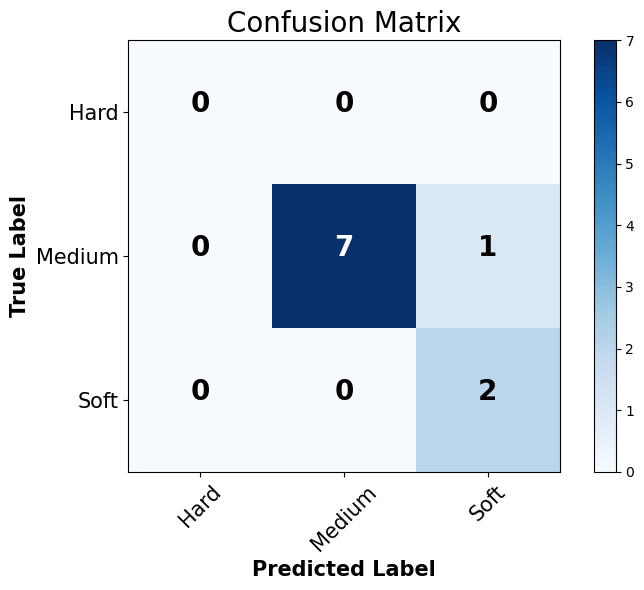

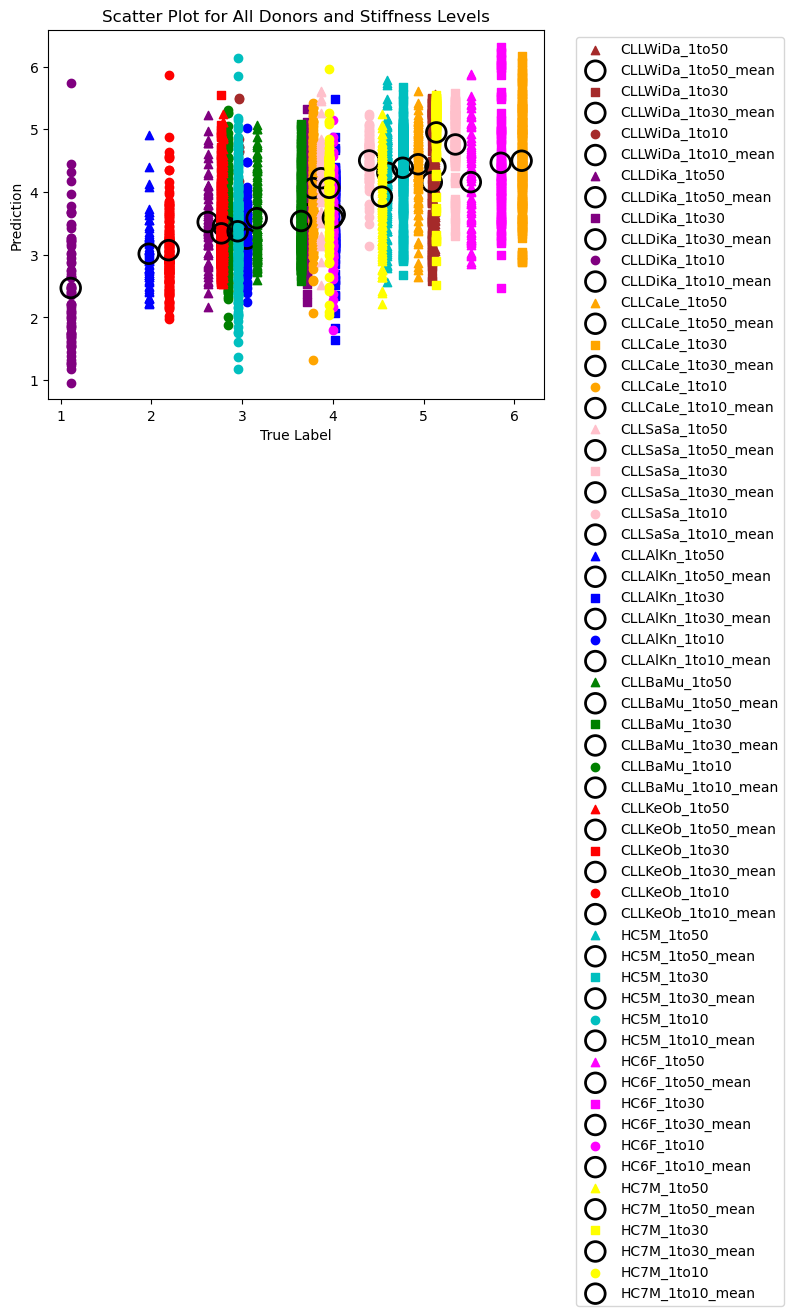

{'CLLWiDa_1to50': [4.762190341949463,
  3.3934788703918457,
  4.865355968475342,
  3.606203317642212,
  4.2092156410217285,
  3.2428314685821533,
  5.533152103424072,
  3.998379945755005,
  5.443766117095947,
  5.565390110015869,
  3.6761438846588135,
  4.174185276031494,
  4.241633892059326,
  4.710733890533447,
  4.781243324279785,
  5.085386753082275,
  4.901424884796143,
  3.0945181846618652,
  4.432897090911865,
  4.171886920928955,
  4.0643086433410645,
  4.310812950134277,
  5.011396884918213,
  5.2849249839782715,
  5.499274253845215,
  5.339285850524902,
  3.0555660724639893,
  5.3077545166015625,
  3.294689416885376,
  4.364060401916504,
  4.505198955535889,
  4.618634223937988,
  3.602330207824707,
  3.379789113998413,
  5.470892906188965,
  4.146286487579346,
  4.568064212799072,
  5.271960258483887,
  5.335827827453613,
  5.165918350219727,
  4.84538459777832,
  3.4352633953094482,
  3.5379350185394287,
  3.5539283752441406,
  4.662781238555908,
  3.4975521564483643,
  5.2

In [31]:
test_net(model, testloader, num = number_of_imgs(root_test))


In [30]:
#stiffness ranking

import re
import numpy as np
import matplotlib.pyplot as plt


def rank_stiffness(result, all_filenames):
    idx = result[:, 1]
    pred = result[:, 2]

    donor_stiffness_dict = {}  # Dictionary to store predicted values for each donor-stiffness combination



    for i in idx:
        i = int(i)
        curr_identity = all_filenames[i].split('/')[-1]
        donor = curr_identity.split('_')[0]
        stiffness_level = curr_identity.split('_')[2]
        image_name = '_'.join([donor, stiffness_level])

        # Update dictionary with predicted value for each donor-stiffness combination
        if image_name in donor_stiffness_dict:
            donor_stiffness_dict[image_name].append(pred[i])
        else:
            donor_stiffness_dict[image_name] = [pred[i]]
            
    # Plot distribution of predictions for each donor and stiffness condition
    plot_predictions_distribution(donor_stiffness_dict)

def plot_predictions_distribution(donor_stiffness_dict):
    donors = set([key.split('_')[0] for key in donor_stiffness_dict.keys()])  # Extract unique donor names
    stiffness_levels = list(set([key.split('_')[1] for key in donor_stiffness_dict.keys()]))  # Convert to list
    colors = ['b', 'r', 'g']  # Define colors for each stiffness level

    # Combine all predictions from all donors
    all_predictions = []
    for predictions_list in donor_stiffness_dict.values():
        all_predictions.extend(predictions_list)

    # Determine overall minimum and maximum predicted values
    min_prediction = min(all_predictions)
    max_prediction = max(all_predictions)
    # Determine the number of bins based on the desired bin width
    bin_width = 0.08  # Adjust bin width as needed
    num_bins = int((max_prediction - min_prediction) / bin_width)

    fig, axs = plt.subplots(len(donors), 1, figsize=(10, 5 * len(donors)))

    for donor_idx, donor in enumerate(donors):
        donor_predictions = []

        ax = axs[donor_idx] if len(donors) > 1 else axs  # Select subplot if there are multiple donors

        for stiffness_idx, stiffness_level in enumerate(stiffness_levels):
            key = f"{donor}_{stiffness_level}"
            if key in donor_stiffness_dict:
                predictions = donor_stiffness_dict[key]
                donor_predictions.extend(predictions)
                ax.hist(predictions, bins=num_bins, range=(min_prediction, max_prediction), alpha=0.5, label=stiffness_level, color=colors[stiffness_idx])
                # Calculate the mean and plot a vertical line
                mean_value = np.mean(predictions)
                ax.axvline(
                    mean_value,
                    color=colors[stiffness_idx],
                    linestyle='--',
                    linewidth=2,
                    label=f"{stiffness_level} mean"
                )
            # Calculate and plot the mean value for all predictions of the donor
        
        ax.set_title(f'Donor: {donor}')
        ax.set_xlabel('Predicted Values')
        ax.set_ylabel('Frequency')
        ax.legend()


    plt.tight_layout()
    plt.show()


In [31]:
#for regression
 
import numpy as np
from sklearn.metrics import mean_squared_error


def test_net(net, test_dataloader, num):
  
    net.eval()

    n_test = len(test_dataloader)
    batch_test_r2 = list()
    batch_test_loss = list()
    result = np.zeros((num, 3))
    
    all_labels=[]
    all_predictions=[]
    #img_labels=[]
    #img_predictions=[]


    loss_function = nn.MSELoss().to(device)
    all_filenames = [] 
    
    with torch.no_grad():
        for i, batch in enumerate(test_dataloader):


            # Load a batch and pass it to the GPU
            test_correct = 0
            imgs = batch['image'].to(device)

            labels = batch['label'].float().view(imgs.size(0),1).to(device)
            idx = batch['idx'].int().view(imgs.size(0),1).to(device)

            y_pred = net(imgs)
            
            loss = loss_function(y_pred, labels).item()
            
            #r2 =  r2_score(labels, y_pred)
            batch_test_loss.append(loss)
            #batch_test_r2.append(r2)

            #test_correct = test_correct + (pred_binary == labels).sum().item()
            test_total = labels.size(0)
            #batch_test_accuracy.append(test_correct/test_total)

            batch_result = np.concatenate((labels.cpu().numpy(),idx.cpu().numpy(), y_pred.cpu()), axis=1)
            all_filenames.extend(batch['filename'])
            
            bs_num = bs

            if i == len(test_dataloader)-1:
                result[(i)*bs_num:,:] = batch_result
            else:
                result[(i)*bs_num:(i)*bs_num + bs_num,:] = batch_result
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(y_pred.cpu().numpy())

        test_loss = np.array(batch_test_loss).mean()
    rank_stiffness(result, all_filenames)

DiKa_hard_1.11 has 75 imgs
HC6F_medium_5.85 has 75 imgs
AlKn_hard_3.05 has 75 imgs
HC6F_soft_5.52 has 75 imgs
CaLe_hard_3.78 has 150 imgs
WiDa_soft_5.13 has 65 imgs
CaLe_soft_4.94 has 138 imgs
CaLe_medium_6.08 has 138 imgs
SaSa_medium_5.35 has 75 imgs
HC7M_medium_5.14 has 80 imgs
KeOb_hard_2.19 has 175 imgs
AlKn_soft_1.97 has 75 imgs
HC5M_soft_4.60 has 178 imgs
HC5M_medium_4.77 has 198 imgs
WiDa_medium_5.09 has 70 imgs
BaMu_hard_2.84 has 153 imgs
DiKa_medium_3.72 has 75 imgs
HC7M_soft_4.54 has 125 imgs
BaMu_medium_3.65 has 150 imgs
WiDa_hard_2.96 has 75 imgs
KeOb_soft_2.79 has 175 imgs
SaSa_hard_4.40 has 75 imgs
DiKa_soft_2.62 has 75 imgs
SaSa_soft_3.87 has 75 imgs
HC7M_hard_3.96 has 125 imgs
HC6F_hard_4.00 has 75 imgs
BaMu_soft_3.16 has 150 imgs
HC5M_hard_2.95 has 225 imgs
KeOb_medium_2.77 has 175 imgs
AlKn_medium_4.02 has 75 imgs




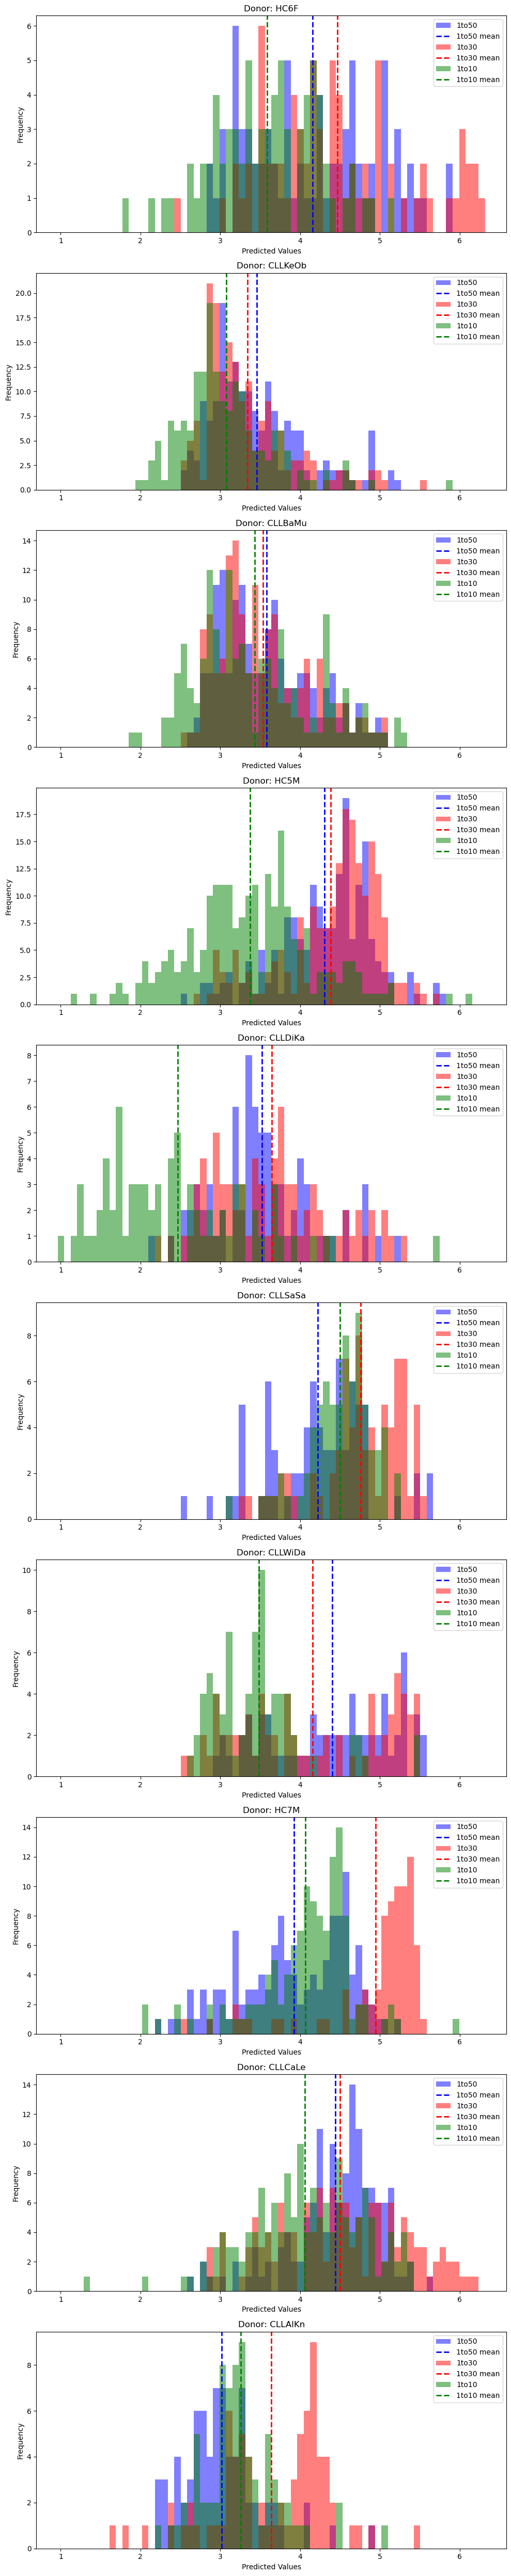

In [32]:
donor_stiff_pred = test_net(model, testloader, num = number_of_imgs(root_test))